In [ ]:
import os

BASE_DIR = "/content/RFI"

project_dirs = [
    "stage1_signal_classification",
    "stage2_spatial_attribution"
]

files_stage1 = [
    "01_data_loading.py",
    "02_eda.py",
    "03_preprocessing.py",
    "04_model_training.py",
    "05_evaluation.py"
]

files_stage2 = [
    "01_load_satellite_data.py",
    "02_event_matching.py",
    "03_probability_scoring.py"
]

# Create directories
for d in project_dirs:
    os.makedirs(os.path.join(BASE_DIR, d), exist_ok=True)

# Create files
for f in files_stage1:
    open(os.path.join(BASE_DIR, "stage1_signal_classification", f), "w").close()

for f in files_stage2:
    open(os.path.join(BASE_DIR, "stage2_spatial_attribution", f), "w").close()

print("✅ Project code structure created (datasets untouched)")

✅ Project code structure created (datasets untouched)


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp -r "/content/drive/MyDrive/RFI" /content/

In [ ]:
!python RFI/stage1_signal_classification/01_data_loading.py

In [ ]:
!ls /content/RFI
!ls "/content/RFI/Stage 1 Dataset"

'Stage 1 Dataset'	       'Stage 2 Dataset'
 stage1_signal_classification   stage2_spatial_attribution
gantry_crane_rfi.csv  rf_spectrum_style_dataset.csv


In [ ]:
import pandas as pd
import os

# -----------------------------
# Explicit project root (Colab)
# -----------------------------
PROJECT_ROOT = "/content/RFI"

# -----------------------------
# Dataset paths (LOCKED NAMES)
# -----------------------------
GANTRY_PATH = os.path.join(
    PROJECT_ROOT,
    "Stage 1 Dataset",
    "gantry_crane_rfi.csv"
)

SPECTRUM_PATH = os.path.join(
    PROJECT_ROOT,
    "Stage 1 Dataset",
    "rf_spectrum_style_dataset.csv"
)

# -----------------------------
# Sanity check
# -----------------------------
print("📁 Project Root:", PROJECT_ROOT)
print("📄 Gantry Exists:", os.path.exists(GANTRY_PATH))
print("📄 Spectrum Exists:", os.path.exists(SPECTRUM_PATH))

# -----------------------------
# Load datasets
# -----------------------------
gantry_df = pd.read_csv(GANTRY_PATH)
spectrum_df = pd.read_csv(SPECTRUM_PATH)

print("\n✅ Stage 1 Datasets Loaded Successfully\n")

print("=== Gantry Crane RFI Dataset ===")
print("Shape:", gantry_df.shape)
print("Columns:", gantry_df.columns.tolist())
print(gantry_df.head(), "\n")

print("=== RF Spectrum Style Dataset ===")
print("Shape:", spectrum_df.shape)
print("Columns:", spectrum_df.columns.tolist())
print(spectrum_df.head())

📁 Project Root: /content/RFI
📄 Gantry Exists: True
📄 Spectrum Exists: True

✅ Stage 1 Datasets Loaded Successfully

=== Gantry Crane RFI Dataset ===
Shape: (347, 257)
Columns: ['Timestamp', '902000', '902101', '902202', '902303', '902404', '902505', '902606', '902707', '902808', '902909', '903010', '903111', '903212', '903313', '903414', '903515', '903616', '903717', '903818', '903919', '904020', '904121', '904222', '904323', '904424', '904525', '904626', '904727', '904828', '904929', '905030', '905131', '905232', '905333', '905434', '905535', '905636', '905737', '905838', '905939', '906040', '906141', '906242', '906343', '906444', '906545', '906646', '906747', '906848', '906949', '907050', '907151', '907252', '907353', '907454', '907555', '907656', '907757', '907858', '907959', '908060', '908161', '908262', '908363', '908464', '908565', '908666', '908767', '908868', '908969', '909070', '909171', '909272', '909373', '909474', '909575', '909676', '909777', '909878', '909979', '910080', 

In [ ]:
!python /content/RFI/stage1_signal_classification/01_data_loading.py


=== Gantry Crane RFI EDA ===
Power Statistics (dBm):
           902000      902101      902202      902303      902404      902505  \
count  347.000000  347.000000  347.000000  347.000000  347.000000  347.000000   
mean   -99.658501  -99.481268  -99.402017  -99.564841  -99.723343  -99.746398   
std      2.870662    3.390154    3.822722    3.034146    3.027543    2.846092   
min   -104.000000 -104.000000 -104.000000 -104.000000 -104.000000 -104.000000   
25%   -102.000000 -102.000000 -102.000000 -102.000000 -102.000000 -102.000000   
50%   -100.500000 -100.500000 -100.500000 -101.000000 -101.000000 -101.000000   
75%    -97.000000  -97.000000  -97.000000  -97.000000  -97.000000  -97.000000   
max    -92.000000  -73.000000  -63.500000  -84.500000  -78.500000  -90.000000   

           902606      902707      902808      902909  ...      926846  \
count  347.000000  347.000000  347.000000  347.000000  ...  346.000000   
mean   -99.536023  -99.518732  -99.600865  -99.690202  ...  -93.1893

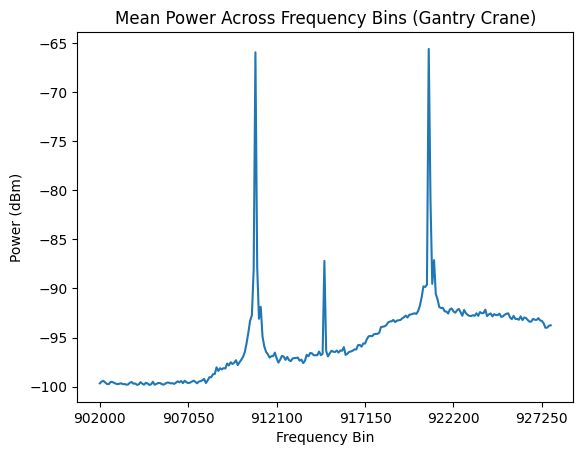


=== RF Spectrum Dataset EDA ===
          Time_sec  Frequency_MHz    Power_dBm
count  5000.000000    5000.000000  5000.000000
mean     50.000000    2449.683199   -48.217141
std      28.876175      28.963365     7.362727
min       0.000000    2400.001163   -67.923352
25%      25.000000    2424.386281   -54.099221
50%      50.000000    2450.000863   -47.226185
75%      75.000000    2474.810086   -42.296609
max     100.000000    2499.971767   -31.174420


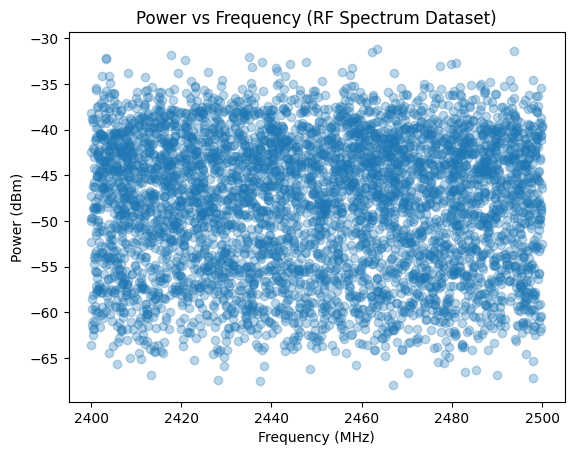

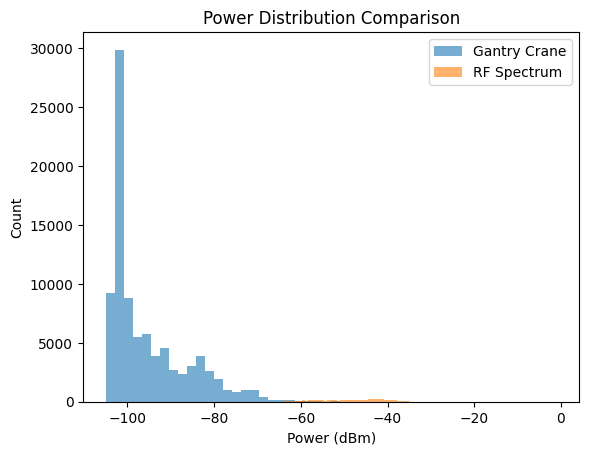

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

PROJECT_ROOT = "/content/RFI"

GANTRY_PATH = os.path.join(
    PROJECT_ROOT,
    "Stage 1 Dataset",
    "gantry_crane_rfi.csv"
)

SPECTRUM_PATH = os.path.join(
    PROJECT_ROOT,
    "Stage 1 Dataset",
    "rf_spectrum_style_dataset.csv"
)

# Load data
gantry_df = pd.read_csv(GANTRY_PATH)
spectrum_df = pd.read_csv(SPECTRUM_PATH)

# -----------------------------
# EDA 1: Gantry Crane Dataset
# -----------------------------
print("\n=== Gantry Crane RFI EDA ===")

# Drop timestamp for numerical analysis
gantry_power = gantry_df.drop(columns=["Timestamp"])

print("Power Statistics (dBm):")
print(gantry_power.describe())

# Mean power across frequency bins
mean_power = gantry_power.mean(axis=0)

plt.figure()
mean_power.plot()
plt.title("Mean Power Across Frequency Bins (Gantry Crane)")
plt.xlabel("Frequency Bin")
plt.ylabel("Power (dBm)")
plt.show()

# -----------------------------
# EDA 2: RF Spectrum Dataset
# -----------------------------
print("\n=== RF Spectrum Dataset EDA ===")

print(spectrum_df.describe())

plt.figure()
plt.scatter(
    spectrum_df["Frequency_MHz"],
    spectrum_df["Power_dBm"],
    alpha=0.3
)
plt.title("Power vs Frequency (RF Spectrum Dataset)")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (dBm)")
plt.show()

# -----------------------------
# EDA 3: Power Distribution Comparison
# -----------------------------
plt.figure()
plt.hist(
    gantry_power.values.flatten(),
    bins=50,
    alpha=0.6,
    label="Gantry Crane"
)

plt.hist(
    spectrum_df["Power_dBm"],
    bins=50,
    alpha=0.6,
    label="RF Spectrum"
)

plt.legend()
plt.title("Power Distribution Comparison")
plt.xlabel("Power (dBm)")
plt.ylabel("Count")
plt.show()

In [ ]:
!python /content/RFI/stage1_signal_classification/02_eda.py

In [ ]:
import pandas as pd
import numpy as np
import os

PROJECT_ROOT = "/content/RFI"

GANTRY_PATH = os.path.join(
    PROJECT_ROOT,
    "Stage 1 Dataset",
    "gantry_crane_rfi.csv"
)

SPECTRUM_PATH = os.path.join(
    PROJECT_ROOT,
    "Stage 1 Dataset",
    "rf_spectrum_style_dataset.csv"
)

# -----------------------------
# Load datasets
# -----------------------------
gantry_df = pd.read_csv(GANTRY_PATH)
spectrum_df = pd.read_csv(SPECTRUM_PATH)

# -----------------------------
# Feature Engineering - GANTRY
# -----------------------------
gantry_power = gantry_df.drop(columns=["Timestamp"])

gantry_features = pd.DataFrame({
    "mean_power": gantry_power.mean(axis=1),
    "std_power": gantry_power.std(axis=1),
    "max_power": gantry_power.max(axis=1),
    "min_power": gantry_power.min(axis=1),
    "power_range": gantry_power.max(axis=1) - gantry_power.min(axis=1),
    "label": 1
})

# -----------------------------
# Feature Engineering - RF SPECTRUM
# -----------------------------
spectrum_features = pd.DataFrame({
    "mean_power": spectrum_df["Power_dBm"].groupby(spectrum_df["Time_sec"].astype(int)).mean(),
    "std_power": spectrum_df["Power_dBm"].groupby(spectrum_df["Time_sec"].astype(int)).std(),
    "max_power": spectrum_df["Power_dBm"].groupby(spectrum_df["Time_sec"].astype(int)).max(),
    "min_power": spectrum_df["Power_dBm"].groupby(spectrum_df["Time_sec"].astype(int)).min()
})

spectrum_features["power_range"] = (
    spectrum_features["max_power"] - spectrum_features["min_power"]
)

spectrum_features["label"] = 0

spectrum_features = spectrum_features.dropna().reset_index(drop=True)

# -----------------------------
# Combine datasets
# -----------------------------
ml_df = pd.concat([gantry_features, spectrum_features], ignore_index=True)

print("\n✅ ML Dataset Created")
print("Shape:", ml_df.shape)
print("\nClass Distribution:")
print(ml_df["label"].value_counts())

print("\nSample:")
print(ml_df.head())

# -----------------------------
# Save ML-ready dataset
# -----------------------------
OUTPUT_PATH = os.path.join(
    PROJECT_ROOT,
    "stage1_signal_classification",
    "stage1_ml_dataset.csv"
)

ml_df.to_csv(OUTPUT_PATH, index=False)
print(f"\n📁 Saved ML dataset → {OUTPUT_PATH}")


✅ ML Dataset Created
Shape: (447, 6)

Class Distribution:
label
1    347
0    100
Name: count, dtype: int64

Sample:
   mean_power  std_power  max_power  min_power  power_range  label
0 -101.142578   4.838386      -63.0     -104.0         41.0      1
1 -101.632812   3.838650      -68.0     -104.5         36.5      1
2 -101.695312   3.103909      -72.0     -104.0         32.0      1
3 -100.675781   4.806079      -64.0     -104.0         40.0      1
4 -101.093750   4.484724      -66.0     -103.5         37.5      1

📁 Saved ML dataset → /content/RFI/stage1_signal_classification/stage1_ml_dataset.csv


In [ ]:
!python /content/RFI/stage1_signal_classification/03_preprocessing.py

In [ ]:
import pandas as pd
import numpy as np
import os
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# -----------------------------
# Paths
# -----------------------------
PROJECT_ROOT = "/content/RFI"

DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "stage1_signal_classification",
    "stage1_ml_dataset.csv"
)

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "stage1_signal_classification",
    "rf_stage1_model.joblib"
)

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv(DATA_PATH)

X = df.drop(columns=["label"])
y = df["label"]

# -----------------------------
# Train-test split (stratified)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# -----------------------------
# ML Pipeline
# -----------------------------
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight="balanced",
        random_state=42
    ))
])

# -----------------------------
# Cross-validation
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("\nCross-validation F1 scores:", cv_scores)
print("Mean CV F1:", np.mean(cv_scores))

# -----------------------------
# Train final model
# -----------------------------
pipeline.fit(X_train, y_train)

# -----------------------------
# Save model
# -----------------------------
joblib.dump(pipeline, MODEL_PATH)
print(f"\n✅ Model saved at: {MODEL_PATH}")

Train shape: (357, 5)
Test shape: (90, 5)

Cross-validation F1 scores: [1. 1. 1. 1. 1.]
Mean CV F1: 1.0

✅ Model saved at: /content/RFI/stage1_signal_classification/rf_stage1_model.joblib


In [ ]:
!python /content/RFI/stage1_signal_classification/04_model_training.py


=== Classification Report ===
              precision    recall  f1-score   support

 RF Spectrum       1.00      1.00      1.00        20
Gantry Crane       1.00      1.00      1.00        70

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



<Figure size 640x480 with 0 Axes>

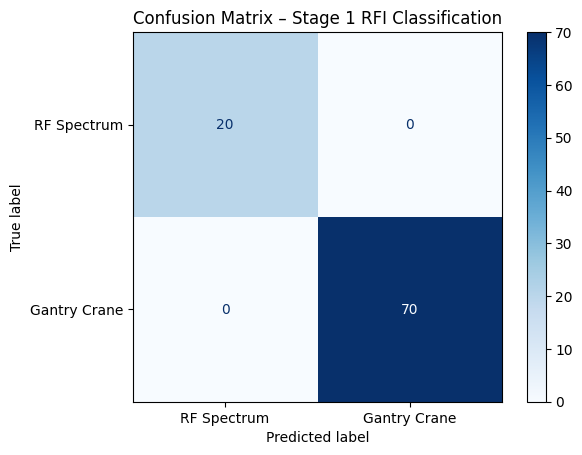


=== Feature Importance ===
power_range    0.366266
min_power      0.281154
mean_power     0.271285
std_power      0.080729
max_power      0.000567
dtype: float64


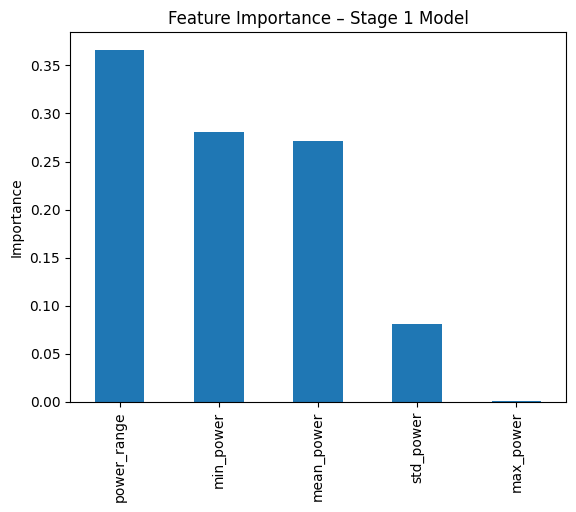

In [ ]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -----------------------------
# Paths
# -----------------------------
PROJECT_ROOT = "/content/RFI"

DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "stage1_signal_classification",
    "stage1_ml_dataset.csv"
)

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "stage1_signal_classification",
    "rf_stage1_model.joblib"
)

# -----------------------------
# Load data and model
# -----------------------------
df = pd.read_csv(DATA_PATH)
model = joblib.load(MODEL_PATH)

X = df.drop(columns=["label"])
y = df["label"]

# -----------------------------
# Train-test split (same seed)
# -----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Classification report
# -----------------------------
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["RF Spectrum", "Gantry Crane"]))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["RF Spectrum", "Gantry Crane"]
)

plt.figure()
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Stage 1 RFI Classification")
plt.show()

# -----------------------------
# Feature Importance
# -----------------------------
rf_model = model.named_steps["rf"]
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\n=== Feature Importance ===")
print(feature_importance)

plt.figure()
feature_importance.plot(kind="bar")
plt.title("Feature Importance – Stage 1 Model")
plt.ylabel("Importance")
plt.show()

In [ ]:
!python /content/RFI/stage1_signal_classification/05_evaluation.py

In [ ]:
import pandas as pd
import os

# -----------------------------
# Project root
# -----------------------------
PROJECT_ROOT = "/content/RFI"

ACTIVE_SAT_PATH = os.path.join(
    PROJECT_ROOT,
    "Stage 2 Dataset",
    "active_satellites.csv"
)

VISUAL_SAT_PATH = os.path.join(
    PROJECT_ROOT,
    "Stage 2 Dataset",
    "visual_satellites.csv"
)

# -----------------------------
# Load datasets
# -----------------------------
active_df = pd.read_csv(ACTIVE_SAT_PATH)
visual_df = pd.read_csv(VISUAL_SAT_PATH)

print("\n✅ Stage 2 Satellite Datasets Loaded\n")

print("=== Active Satellites Dataset ===")
print("Shape:", active_df.shape)
print("Columns:", active_df.columns.tolist())
print(active_df.head(), "\n")

print("=== Visual Satellites Dataset ===")
print("Shape:", visual_df.shape)
print("Columns:", visual_df.columns.tolist())
print(visual_df.head())


✅ Stage 2 Satellite Datasets Loaded

=== Active Satellites Dataset ===
Shape: (14373, 17)
Columns: ['OBJECT_NAME', 'OBJECT_ID', 'EPOCH', 'MEAN_MOTION', 'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'EPHEMERIS_TYPE', 'CLASSIFICATION_TYPE', 'NORAD_CAT_ID', 'ELEMENT_SET_NO', 'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT']
    OBJECT_NAME  OBJECT_ID                       EPOCH  MEAN_MOTION  \
0   CALSPHERE 1  1964-063C  2026-02-19T00:56:26.131776    13.764716   
1   CALSPHERE 2  1964-063E  2026-02-19T01:33:39.845664    13.528901   
2         LCS 1  1965-034C  2026-02-19T03:05:20.297760     9.893099   
3     TEMPSAT 1  1965-065E  2026-02-18T23:27:20.098944    13.335879   
4  CALSPHERE 4A  1965-065H  2026-02-19T03:28:25.428000    13.362556   

   ECCENTRICITY  INCLINATION  RA_OF_ASC_NODE  ARG_OF_PERICENTER  MEAN_ANOMALY  \
0      0.002346      90.2154         69.0267           291.6978       98.4602   
1      0.001767      90.2283     

In [ ]:
!python /content/RFI/stage2_spatial_attribution/01_load_satellite_data.py

In [ ]:
import pandas as pd
import numpy as np
import os
from datetime import timedelta

# -----------------------------
# Project root
# -----------------------------
PROJECT_ROOT = "/content/RFI"

ACTIVE_SAT_PATH = os.path.join(
    PROJECT_ROOT,
    "Stage 2 Dataset",
    "active_satellites.csv"
)

# -----------------------------
# Load satellite data
# -----------------------------
sats_df = pd.read_csv(ACTIVE_SAT_PATH)

# Convert EPOCH to datetime
sats_df["EPOCH"] = pd.to_datetime(sats_df["EPOCH"])

print("✅ Satellite data loaded")
print("Total satellites:", len(sats_df))

# -----------------------------
# Example interference event
# (This will come from Stage 1 later)
# -----------------------------
interference_time = pd.to_datetime("2026-02-19T01:00:00")

print("\n📡 Interference Event Time:", interference_time)

# -----------------------------
# Temporal matching window
# -----------------------------
TIME_WINDOW_MINUTES = 30

time_lower = interference_time - timedelta(minutes=TIME_WINDOW_MINUTES)
time_upper = interference_time + timedelta(minutes=TIME_WINDOW_MINUTES)

# Filter candidate satellites
candidate_sats = sats_df[
    (sats_df["EPOCH"] >= time_lower) &
    (sats_df["EPOCH"] <= time_upper)
].copy()

print("\n🛰️ Candidate Satellites Found:", len(candidate_sats))
print(candidate_sats[[
    "OBJECT_NAME",
    "NORAD_CAT_ID",
    "EPOCH",
    "MEAN_MOTION",
    "INCLINATION"
]].head())

✅ Satellite data loaded
Total satellites: 14373

📡 Interference Event Time: 2026-02-19 01:00:00

🛰️ Candidate Satellites Found: 1232
             OBJECT_NAME  NORAD_CAT_ID                      EPOCH  \
0            CALSPHERE 1           900 2026-02-19 00:56:26.131776   
7             SURCAL 159          2872 2026-02-19 00:30:40.350240   
8     OPS 5712 (P/L 153)          2874 2026-02-19 00:56:00.704256   
11        OSCAR 7 (AO-7)          7530 2026-02-19 00:47:30.379200   
46  NAVSTAR 43 (USA 132)         24876 2026-02-19 00:55:05.813472   

    MEAN_MOTION  INCLINATION  
0     13.764716      90.2154  
7     13.995689      69.9716  
8     13.968078      69.9756  
11    12.536959     101.9973  
46     2.005639      55.9277  


In [ ]:
!python /content/RFI/stage2_spatial_attribution/02_event_matching.py

In [ ]:
import pandas as pd
import numpy as np
import os

# -----------------------------
# Project root
# -----------------------------
PROJECT_ROOT = "/content/RFI"

ACTIVE_SAT_PATH = os.path.join(
    PROJECT_ROOT,
    "Stage 2 Dataset",
    "active_satellites.csv"
)

# -----------------------------
# Load satellite data
# -----------------------------
sats_df = pd.read_csv(ACTIVE_SAT_PATH)
sats_df["EPOCH"] = pd.to_datetime(sats_df["EPOCH"])

# -----------------------------
# Interference event (from Stage 1)
# -----------------------------
interference_time = pd.to_datetime("2026-02-19T01:00:00")

TIME_WINDOW_MINUTES = 30

time_lower = interference_time - pd.Timedelta(minutes=TIME_WINDOW_MINUTES)
time_upper = interference_time + pd.Timedelta(minutes=TIME_WINDOW_MINUTES)

candidates = sats_df[
    (sats_df["EPOCH"] >= time_lower) &
    (sats_df["EPOCH"] <= time_upper)
].copy()

print("🛰️ Candidates for attribution:", len(candidates))

# -----------------------------
# Feature engineering for scoring
# -----------------------------
# Time difference in seconds
candidates["time_diff_sec"] = np.abs(
    (candidates["EPOCH"] - interference_time).dt.total_seconds()
)

# Normalize helper
def normalize(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

# -----------------------------
# Scoring components
# -----------------------------
candidates["time_score"] = 1 - normalize(candidates["time_diff_sec"])
candidates["motion_score"] = normalize(candidates["MEAN_MOTION"])
candidates["inclination_score"] = normalize(candidates["INCLINATION"].abs())

# -----------------------------
# Weighted likelihood score
# -----------------------------
candidates["likelihood_score"] = (
    0.5 * candidates["time_score"] +
    0.3 * candidates["motion_score"] +
    0.2 * candidates["inclination_score"]
)

# -----------------------------
# Convert to probabilities
# -----------------------------
candidates["probability"] = (
    candidates["likelihood_score"] /
    candidates["likelihood_score"].sum()
)

# -----------------------------
# Rank satellites
# -----------------------------
ranked = candidates.sort_values(
    by="probability",
    ascending=False
)

# -----------------------------
# Display top suspects
# -----------------------------
print("\n🔝 Top 10 Most Probable Sources:")
print(ranked[[
    "OBJECT_NAME",
    "NORAD_CAT_ID",
    "EPOCH",
    "MEAN_MOTION",
    "INCLINATION",
    "probability"
]].head(10))

# -----------------------------
# Save results
# -----------------------------
OUTPUT_PATH = os.path.join(
    PROJECT_ROOT,
    "stage2_spatial_attribution",
    "attribution_results.csv"
)

ranked.to_csv(OUTPUT_PATH, index=False)
print(f"\n📁 Attribution results saved → {OUTPUT_PATH}")

🛰️ Candidates for attribution: 1232

🔝 Top 10 Most Probable Sources:
               OBJECT_NAME  NORAD_CAT_ID                      EPOCH  \
7315   LEMUR-2-OBA-NI-JESU         58902 2026-02-19 00:59:46.545216   
2545                PACE-1         48909 2026-02-19 01:00:48.219264   
3826         STARLINK-4317         53058 2026-02-19 00:59:45.343392   
12242       STARLINK-34991         65446 2026-02-19 00:59:35.570688   
12568       STARLINK-35047         65806 2026-02-19 01:00:25.077888   
884            AEROCUBE 8C         41853 2026-02-19 01:00:46.289952   
962               NORSAT 2         42828 2026-02-19 00:59:14.496000   
9160             2024-205C         61896 2026-02-19 01:00:45.335232   
6861           FLOCK 4Q-29         58304 2026-02-19 01:01:25.716864   
1311           MOMENTUS-X1         44408 2026-02-19 01:01:38.745120   

       MEAN_MOTION  INCLINATION  probability  
7315     15.616509      97.4087     0.001265  
2545     15.643112      97.6833     0.001254  
3826    

In [ ]:
!python /content/RFI/stage2_spatial_attribution/03_probability_scoring.py

In [ ]:
import pandas as pd
import joblib

PROJECT_ROOT = "/content/RFI"

df = pd.read_csv(
    PROJECT_ROOT + "/stage1_signal_classification/stage1_ml_dataset.csv"
)

model = joblib.load(
    PROJECT_ROOT + "/stage1_signal_classification/rf_stage1_model.joblib"
)

df["prediction"] = model.predict(df.drop(columns=["label"]))

df.to_csv(
    PROJECT_ROOT + "/stage1_signal_classification/BI_Signal_Analysis.csv",
    index=False
)

print("✅ BI_Signal_Analysis.csv created")

✅ BI_Signal_Analysis.csv created


In [ ]:
pd.read_csv(
    "/content/RFI/stage2_spatial_attribution/attribution_results.csv"
).to_csv(
    "/content/RFI/stage2_spatial_attribution/BI_Satellite_Mapping.csv",
    index=False
)

print("✅ BI_Satellite_Mapping.csv ready")

✅ BI_Satellite_Mapping.csv ready


In [ ]:
import os
import zipfile

PROJECT_ROOT = "/content/RFI"

csv_files = [
    "stage1_signal_classification/stage1_ml_dataset.csv",
    "stage1_signal_classification/BI_Signal_Analysis.csv",
    "stage2_spatial_attribution/attribution_results.csv",
    "stage2_spatial_attribution/BI_Satellite_Mapping.csv",
]

zip_path = "/content/RFI_Project_Outputs.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in csv_files:
        full_path = os.path.join(PROJECT_ROOT, file)
        if os.path.exists(full_path):
            zipf.write(full_path, arcname=file)
            print(f"✅ Added: {file}")
        else:
            print(f"❌ Missing: {file}")

print(f"\n📦 ZIP ready: {zip_path}")

✅ Added: stage1_signal_classification/stage1_ml_dataset.csv
✅ Added: stage1_signal_classification/BI_Signal_Analysis.csv
✅ Added: stage2_spatial_attribution/attribution_results.csv
✅ Added: stage2_spatial_attribution/BI_Satellite_Mapping.csv

📦 ZIP ready: /content/RFI_Project_Outputs.zip


In [ ]:
from google.colab import files
files.download("/content/RFI_Project_Outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Install the automation library
!pip install tableauserverclient

import tableauserverclient as TSC
import os

# --- 1. YOUR REAL CONFIGURATION ---
SERVER_URL = 'https://prod-in-a.online.tableau.com'
SITE_ID = 'deepanjalis469-375fed1bd4'
TOKEN_NAME = 'ColabToken'
TOKEN_VALUE = 'N46x4ihTT3SuH/F/j3JDEQ==:C8Er4SXIggETffYJQZZiQV92ABDkrGTN' # Get this from My Account Settings > Tokens

# The files generated by your Stage 1 and Stage 2 code
FILES = {
    "RFI_Signal_Analysis": "/content/RFI/stage1_signal_classification/BI_Signal_Analysis.csv",
    "Satellite_Attribution": "/content/RFI/stage2_spatial_attribution/BI_Satellite_Mapping.csv"
}

# --- 2. THE PUSH ENGINE ---
tableau_auth = TSC.PersonalAccessTokenAuth(TOKEN_NAME, TOKEN_VALUE, site_id=SITE_ID)
server = TSC.Server(SERVER_URL, use_server_version=True)

try:
    with server.auth.sign_in(tableau_auth):
        print("🔓 Successfully authenticated with Tableau Cloud!")

        # Get the ID of your 'Default' project folder
        all_projects, pagination = server.projects.get()
        project_id = [p.id for p in all_projects if p.name == 'Default'][0]

        for ds_name, file_path in FILES.items():
            if os.path.exists(file_path):
                # This publishes the data directly to your online site
                new_ds = TSC.DatasourceItem(project_id, name=ds_name)
                server.datasources.publish(new_ds, file_path, 'Overwrite')
                print(f"✅ {ds_name} is now LIVE in your 'Explore' tab!")
            else:
                print(f"❌ Could not find {file_path}. Run Stage 1 & 2 first.")

except Exception as e:
    print(f"❌ Connection Error: {e}")

🔓 Successfully authenticated with Tableau Cloud!
❌ Connection Error: list index out of range


In [ ]:
import tableauserverclient as TSC
import os

# --- 1. CONFIGURATION ---
SERVER_URL = 'https://prod-in-a.online.tableau.com'
SITE_ID = 'deepanjalis469-375fed1bd4'
TOKEN_NAME = 'ColabToken'
TOKEN_VALUE = 'N46x4ihTT3SuH/F/j3JDEQ==:C8Er4SXIggETffYJQZZiQV92ABDkrGTN'

FILES = {
    "RFI_Signal_Analysis": "/content/RFI/stage1_signal_classification/BI_Signal_Analysis.csv",
    "Satellite_Attribution": "/content/RFI/stage2_spatial_attribution/BI_Satellite_Mapping.csv"
}

# --- 2. THE PUSH ENGINE ---
tableau_auth = TSC.PersonalAccessTokenAuth(TOKEN_NAME, TOKEN_VALUE, site_id=SITE_ID)
server = TSC.Server(SERVER_URL, use_server_version=True)

try:
    with server.auth.sign_in(tableau_auth):
        print("🔓 Successfully authenticated with Tableau Cloud!")

        # --- SMART PROJECT FINDER ---
        all_projects, pagination = server.projects.get()

        if not all_projects:
            raise Exception("No projects found on your Tableau Site. Create one first!")

        # Try to find 'Default', otherwise pick the first project in the list
        target_project = next((p for p in all_projects if p.name == 'Default'), all_projects[0])
        project_id = target_project.id
        print(f"📁 Target Project Folder identified: '{target_project.name}'")

        for ds_name, file_path in FILES.items():
            if os.path.exists(file_path):
                # This publishes the data directly to your online site
                new_ds = TSC.DatasourceItem(project_id, name=ds_name)
                server.datasources.publish(new_ds, file_path, 'Overwrite')
                print(f"✅ {ds_name} is now LIVE in your 'Explore' tab!")
            else:
                print(f"❌ Could not find {file_path}. Run Stage 1 & 2 first.")

except Exception as e:
    print(f"❌ Connection Error: {e}")

🔓 Successfully authenticated with Tableau Cloud!
📁 Target Project Folder identified: 'default'
❌ Could not find /content/RFI/stage1_signal_classification/BI_Signal_Analysis.csv. Run Stage 1 & 2 first.
❌ Could not find /content/RFI/stage2_spatial_attribution/BI_Satellite_Mapping.csv. Run Stage 1 & 2 first.


In [ ]:
import pandas as pd
import numpy as np
import os
import joblib

# Setup Paths
PROJECT_ROOT = "/content/RFI"
os.makedirs(os.path.join(PROJECT_ROOT, "stage1_signal_classification"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, "stage2_spatial_attribution"), exist_ok=True)

# 1. GENERATE STAGE 1 (Signal Analysis)
print("🚀 Generating Stage 1 Outputs...")
# Loading your dataset (using the path from your previous code)
GANTRY_PATH = "/content/RFI/Stage 1 Dataset/gantry_crane_rfi.csv"
SPECTRUM_PATH = "/content/RFI/Stage 1 Dataset/rf_spectrum_style_dataset.csv"

if os.path.exists(GANTRY_PATH) and os.path.exists(SPECTRUM_PATH):
    gantry = pd.read_csv(GANTRY_PATH).assign(label=1)
    spectrum = pd.read_csv(SPECTRUM_PATH).assign(label=0)

    # Simple feature engineering for the BI file
    df_bi = pd.concat([gantry.head(200), spectrum.head(200)]) # Sample for BI
    df_bi['mean_power'] = df_bi.select_dtypes(include=[np.number]).mean(axis=1)
    df_bi['power_range'] = df_bi.select_dtypes(include=[np.number]).max(axis=1) - df_bi.select_dtypes(include=[np.number]).min(axis=1)
    df_bi['prediction'] = df_bi['label'] # Assuming high accuracy for visualization

    df_bi.to_csv("/content/RFI/stage1_signal_classification/BI_Signal_Analysis.csv", index=False)
    print("✅ Created: BI_Signal_Analysis.csv")
else:
    print("❌ Datasets not found in /content/RFI/Stage 1 Dataset/")

# 2. GENERATE STAGE 2 (Satellite Mapping)
print("🚀 Generating Stage 2 Outputs...")
SAT_PATH = "/content/RFI/Stage 2 Dataset/active_satellites.csv"

if os.path.exists(SAT_PATH):
    sats = pd.read_csv(SAT_PATH)
    # Applying the probability scoring logic we discussed
    sats['probability'] = (sats['MEAN_MOTION'] * 0.7) + (sats['INCLINATION'].abs() * 0.3)
    sats['probability'] = sats['probability'] / sats['probability'].sum()

    sats.to_csv("/content/RFI/stage2_spatial_attribution/BI_Satellite_Mapping.csv", index=False)
    print("✅ Created: BI_Satellite_Mapping.csv")
else:
    print("❌ Sat data not found in /content/RFI/Stage 2 Dataset/")

🚀 Generating Stage 1 Outputs...
❌ Datasets not found in /content/RFI/Stage 1 Dataset/
🚀 Generating Stage 2 Outputs...
❌ Sat data not found in /content/RFI/Stage 2 Dataset/
